# UMAPを用いて可視化するnotebook

## 全体準備

### ライブラリインポート

In [1]:
#@title Installation & imports
!pip3 install --quiet -U umap-learn 
!pip install --quiet umap-learn 
!pip install --quiet py7zr
!pip install --quiet Levenshtein

import os
from pathlib import Path
import random

import numpy as np
import umap.umap_ as umap
import h5py

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from Levenshtein import distance as distance

import pandas as pd
import matplotlib as mpl
from omegaconf import OmegaConf

import torch
import umap
import requests
import os
import zipfile
import py7zr
import warnings
from tqdm import tqdm

import pretrain

warnings.filterwarnings('ignore')

os.chdir(
    "/workspace"
)  # 変更したいディレクトリのパスを指定
# 現在の作業ディレクトリを確認
print("Current working directory:", os.getcwd())

/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Current working directory: /workspace


### 設定

In [2]:
frameworks = ["data2vec_mlm_02", "data2vec_mlm_08", "data2vec", "mlm", "rinalmo"]
framework_colors = {
    "data2vec": "orange",
    "mlm": "blue",
    "data2vec_mlm_02": "green",
    "data2vec_mlm_08": "purple",
    "rinalmo": "gray",
}
nucleotides = ["A", "C", "G", "U"]
structure_elements = [".", "(", ")", "<", ">"]
family = [
  "5s",
  "16s",
  "23s",
  "grp1",
  "RNaseP",
  "srp_long",
  "srp_short",
  "telomerase",
  "tmRNA",
  "tRNA",
]

framework_path_dict = {
    "data2vec": Path(
        "./results/pretrain_results/data2vec/20260307T153057/"
    ),
    "mlm": Path("./results/pretrain_results/mlm/20260316T030756/"),
    "data2vec_mlm_02": Path("./results/pretrain_results/data2vec/20260324T045257/"),
    "data2vec_mlm_08": Path("./results/pretrain_results/data2vec/20260406T124643/"),
    "rinalmo": Path("./data/embeddings/RiNALMo_ArchiveII.h5"),
}

archiveII_file = pd.read_csv("./data/SS_data/ArchiveII.csv")

# シード値の設定
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## 塩基ごとの表現でクラスタを形成しているか

### 特徴表現の取得

In [3]:
# 表現学習モデルの準備

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

models = {f"{framework_name}": None for framework_name in frameworks}

pretrain.utils.setup_config()

for framework_name in frameworks:
    if framework_name == "rinalmo":
        continue
    
    model_path = framework_path_dict[framework_name]
    if not model_path.exists():
        raise FileNotFoundError(f"Pretrain model path {model_path} does not exist.")

    cfg_path = model_path / f"train_config/.hydra/config.yaml"
    cfg = OmegaConf.load(cfg_path)
    cfg.common.batch_size = cfg.model_size.gradient_accumulation_steps

    if framework_name == "data2vec":
        model = pretrain.models.data2vecModel(
            **cfg.framework,
            padding_idx=cfg.dataset.tokens.index("<pad>"),
            num_tokens=len(cfg.dataset.tokens),
            experiment_cfg=cfg.experiment,
            device=device
        )
    elif framework_name in ["data2vec_mlm_02", "data2vec_mlm_08"]:
        model = pretrain.models.data2vecModel(
            **cfg.framework,
            padding_idx=cfg.dataset.tokens.index("<pad>"),
            num_tokens=len(cfg.dataset.tokens),
            experiment_cfg=cfg.experiment,
            device=device
        )
    elif framework_name == "mlm":
        model = pretrain.models.MLMModel(
            **cfg.framework,
            padding_idx=cfg.dataset.tokens.index("<pad>"),
            num_tokens=len(cfg.dataset.tokens),
            experiment_cfg=cfg.experiment,
            device=device
        )

    ## 事前学習モデルの重みの読み込み
    weight = f"weight_150000.pth"
    print(f"Loading weights from {model_path / weight} for {framework_name}...")
    model._load_state_dict(torch.load(model_path / weight, map_location=device))
    
    models[framework_name] = {
        "model": model,
        "cfg": cfg,
        "dataloader": pretrain.dataset.create_dataloader(config=cfg, split="test")
    }

Using device: cuda
Loading weights from results/pretrain_results/data2vec/20260324T045257/weight_150000.pth for data2vec_mlm_02...
Loading weights from results/pretrain_results/data2vec/20260406T124643/weight_150000.pth for data2vec_mlm_08...
Loading weights from results/pretrain_results/data2vec/20260307T153057/weight_150000.pth for data2vec...
Loading weights from results/pretrain_results/mlm/20260316T030756/weight_150000.pth for mlm...


In [4]:
# メドイド法で選択した代表配列を追加
def select_medoid(sequences: list) -> str:
    """
    配列リストからメドイド（他全配列への距離の総和が最小の配列）を返す
    """
    n = len(sequences)
    if n == 0:
        return None
    if n == 1:
        return sequences[0]

    min_total_dist = float("inf")
    medoid_seq = None

    # 各配列について、他の全ての配列との距離の合計を計算
    for i, seq_i in enumerate(sequences):
        total_dist = 0
        for j, seq_j in enumerate(sequences[i + 1 :], start=i + 1):
            # 配列間の編集距離を加算
            total_dist += distance(str(seq_i), str(seq_j))

        # 合計距離が最小のものを更新
        if total_dist < min_total_dist:
            min_total_dist = total_dist
            medoid_seq = seq_i

    return medoid_seq


fam_representatives = {fam: {} for fam in family}
for fam in family:
    fam_csv = pd.read_csv(f"./data/SS_data/archiveII_famfold/{fam}/test.csv")
    sequences = fam_csv["sequence"].tolist()
    medoid_seq = select_medoid(sequences)

    seq_id = fam_csv[fam_csv["sequence"] == medoid_seq]["id"].values[0]

    fam_representatives[fam] = {
        "id": seq_id,
    }

In [5]:
# 配列表現の抽出
family_representatives = {}
seq_dict_flag = False
seq_dict = {fam: {} for fam in family}
for framework_name in frameworks:
    print(f"Extracting representations for {framework_name}...")
    if framework_name == "rinalmo":
        with h5py.File(framework_path_dict[framework_name], "r") as hdf:
            # 比較対象とする配列の読み込み
            family_representatives[framework_name] = {fam: {} for fam in family}
            for fam in family:
                print(f"Extracting representation for {fam}...")
                seq_id = fam_representatives[fam]["id"]
                family_representatives[framework_name][fam] = {
                    "seq_id": seq_id,
                    "sequence": archiveII_file[archiveII_file["id"] == seq_id][
                        "sequence"
                    ].values[0],
                    "structure": archiveII_file[archiveII_file["id"] == seq_id][
                        "structure"
                    ].values[0],
                    "representation": torch.from_numpy(hdf[seq_id][:]).requires_grad_(
                        False
                    ),
                }
    else:
        family_representatives[framework_name] = {fam: {} for fam in family}
        
        for fam in family:
            if seq_dict_flag:
                continue
            seq_dict[fam]["seq_id"] = fam_representatives[fam]["id"]
            for batch in tqdm(models[framework_name]["dataloader"]):
                assert len(batch["seq_ids"]) == 1, "Batch size should be 1 for representation extraction."
                batch_seq_id = batch["seq_ids"][0]
                if batch_seq_id == seq_dict[fam]["seq_id"]:
                    seq_dict[fam]["batch"] = batch
                    break
                
        seq_dict_flag = True

        for fam, seq_info in seq_dict.items():
            print(f"Extracting representation for {fam}...")
            seq_id = seq_info["seq_id"]
            representation = models[framework_name]["model"]._test(seq_info["batch"])["repr"] # B x L x E
            
            family_representatives[framework_name][fam] = {
                "seq_id": seq_id,
                "sequence": archiveII_file[archiveII_file["id"] == seq_id][
                    "sequence"
                ].values[0],
                "structure": archiveII_file[archiveII_file["id"] == seq_id][
                    "structure"
                ].values[0],
                "representation": representation.squeeze(0).detach(),  # L x E
            }

Extracting representations for data2vec_mlm_02...


 80%|███████▉  | 3073/3864 [00:03<00:00, 877.17it/s]


Extracting representation for 5s...
Extracting representation for 16s...
Extracting representation for 23s...
Extracting representation for grp1...
Extracting representation for RNaseP...
Extracting representation for srp_long...
Extracting representation for srp_short...
Extracting representation for telomerase...
Extracting representation for tmRNA...
Extracting representation for tRNA...
Extracting representations for data2vec_mlm_08...
Extracting representation for 5s...
Extracting representation for 16s...
Extracting representation for 23s...
Extracting representation for grp1...
Extracting representation for RNaseP...
Extracting representation for srp_long...
Extracting representation for srp_short...
Extracting representation for telomerase...
Extracting representation for tmRNA...
Extracting representation for tRNA...
Extracting representations for data2vec...
Extracting representation for 5s...
Extracting representation for 16s...
Extracting representation for 23s...
Extractin

### UMAPの設定

In [6]:
# 可視化の図に乗せるframeworkの名前の表記変更
framework_name_mapping = {
    "data2vec": "data2vec",
    "mlm": "MLM",
    "data2vec_mlm_02": "data2vec+MLM_02",
    "data2vec_mlm_08": "data2vec+MLM_08",
    "rinalmo": "RiNALMo",
}

In [30]:
# 塩基のラベリング
nts = {framework_name: {fam: [] for fam in family} for framework_name in frameworks}
structures = {framework_name: {fam: [] for fam in family} for framework_name in frameworks}

for framework_name in frameworks:
    for fam in family:
        seq = family_representatives[framework_name][fam]["sequence"]
        struct = family_representatives[framework_name][fam]["structure"]
        nts[framework_name][fam] = [nucleotide for nucleotide in seq]
        structures[framework_name][fam] = [elem for elem in struct]


# 塩基の数をカウント
num_nt = {nt: 0 for nt in nucleotides}
for fam in family:
    for nt in nts[framework_name][fam]:
        num_nt[nt] += 1
print("\nNumber of nucleotides across all families:")
for nt, count in num_nt.items():
    print(f"  {nt}: {count}")

# 構造要素の数をカウント
num_struct = {elem: 0 for elem in structure_elements}
for fam in family:
    for elem in structures[framework_name][fam]:
        num_struct[elem] += 1
print("\nNumber of structural elements across all families:")
for elem, count in num_struct.items():
    print(f"  {elem}: {count}")

# ラベルに応じた設定
# 色、z軸の値、アルファ値、順序を塩基ごとに設定
colors = mpl.colormaps["Set1"].colors
nt_color_dict = {nt: colors[i] for i, nt in enumerate(nucleotides)}
nts_colors = {framework_name: {fam: [nt_color_dict[nt] for nt in nts[framework_name][fam]] for fam in family} for framework_name in frameworks}

zs = [10, 8, 6, 4]
nt_zs = {nt: zs[i] for i, nt in enumerate(nucleotides)}
nts_zs = {framework_name: {fam: [nt_zs[nt] for nt in nts[framework_name][fam]] for fam in family} for framework_name in frameworks}

alphas = [0.5, 0.5, 0.5, 0.5]
nt_alphas = {nt: alphas[i] for i, nt in enumerate(nucleotides)}
nts_alphas = {framework_name: {fam: [nt_alphas[nt] for nt in nts[framework_name][fam]] for fam in family} for framework_name in frameworks}

nts_orders = {framework_name: {fam: np.argsort(nts_zs[framework_name][fam]) for fam in family} for framework_name in frameworks}

# 色、z軸の値、アルファ値、順序を構造ごとに設定
structure_color_dict = {elem: colors[i] for i, elem in enumerate(structure_elements)}
structure_colors = {framework_name: {fam: [structure_color_dict[elem] for elem in structures[framework_name][fam]] for fam in family} for framework_name in frameworks}

zs = list(range(0, len(structure_elements) * 2, 2))
structure_zs = {elem: zs[i] for i, elem in enumerate(structure_elements)}
structure_zs_dict = {framework_name: {fam: [structure_zs[elem] for elem in structures[framework_name][fam]] for fam in family} for framework_name in frameworks}

alphas = [0.5 for _ in structure_elements]
alphas[0] = 0.1 # unpairedは少し薄く
structure_alphas = {elem: alphas[i] for i, elem in enumerate(structure_elements)}
structure_alphas_dict = {framework_name: {fam: [structure_alphas[elem] for elem in structures[framework_name][fam]] for fam in family} for framework_name in frameworks}

structure_orders = {framework_name: {fam: np.argsort(structure_zs_dict[framework_name][fam]) for fam in family} for framework_name in frameworks}


Number of nucleotides across all families:
  A: 647
  C: 776
  G: 860
  U: 579

Number of structural elements across all families:
  .: 1352
  (: 707
  ): 707
  <: 48
  >: 48


In [13]:
# UMAPによる次元削減の関数
def get_umap_proj(seq_embeddings: list[torch.Tensor], n_components: int = 3) -> np.ndarray:
    # seq_embeddings: (配列数) x (L x E) 
    E = seq_embeddings[0].shape[1]

    # 各塩基の埋め込みを抽出する
    token_embeddings = torch.cat(seq_embeddings, dim=0).reshape(-1, E).cpu().numpy()  # (B*L) x E

    umap_model = umap.UMAP(random_state=42, n_components=n_components)
    return umap_model.fit_transform(token_embeddings)

In [27]:
# 次元削減の結果のプロット関数
def plot_embedding_3d(data_points, framework_name, family_name: list, ax, type="nt"):
  """
  Args:
    data_points: (B*L) x 3の次元削減された埋め込みベクトル
    framework_name: 可視化するフレームワークの名前
    family_name: 可視化するファミリーの名前のリスト
    ax: プロットするmatplotlibのAxesオブジェクト
    type: "nt"なら塩基ごと、"struct"なら構造要素ごとに色分け
  """

  # markers
  #plt.rc('axes.spines', **{'bottom':True, 'left':True, 'right':False, 'top':False})
  #fig = plt.figure()
  #ax=fig.add_subplot(projection='3d')
  # Hide grid lines
  ax.grid(False)

  ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
  ax.set_axis_off()
  ax.set_ylim(-6.91, 24.93)
  ax.set_xlim(-9.18, 23.48)
  ax.set_zlim(-12.39, 23.63)
  vleng = 22

  i = np.array([vleng, 0, 0])
  j = np.array([0, vleng, 0])
  k = np.array([0, 0, vleng])

  p = np.array([vleng, 0, vleng])
  q = np.array([0, vleng, vleng])
  r = np.array([vleng, vleng, 0])

  ax_color = '0.8'
  ax.plot(*np.vstack([[0,0,0], i]).T, color=ax_color)
  ax.plot(*np.vstack([[0,0,0], j]).T, color=ax_color)
  ax.plot(*np.vstack([[0,0,0], k]).T, color=ax_color)
  ax.plot(*np.vstack([[0,0,vleng], p]).T, color=ax_color)
  ax.plot(*np.vstack([[0,0,vleng], q]).T, color=ax_color)
  ax.plot(*np.vstack([[vleng,0,0], r]).T, color=ax_color)
  ax.plot(*np.vstack([[0,vleng,0], r]).T, color=ax_color)
  ax.plot(*np.vstack([[0,vleng,0], q]).T, color=ax_color)
  ax.plot(*np.vstack([[vleng,0,0], p]).T, color=ax_color)

  ax.view_init(22, 25)

  if family_name[0].upper() == "ALL":
    family_name = family

  for fam in family_name:
    if type == "nt":
      order = nts_orders[framework_name][fam]
      color = nts_colors[framework_name][fam]
      alpha = nts_alphas[framework_name][fam]
    else:
      order = structure_orders[framework_name][fam]
      color = structure_colors[framework_name][fam]
      alpha = structure_alphas_dict[framework_name][fam]

    sc = ax.scatter(data_points[:, 0][order], data_points[:, 1][order], data_points[:, 2][order], c=[color[i] for i in order], alpha=0.5)

  plt.title(f'{framework_name_mapping.get(framework_name, framework_name)}')
  if type == "nt":
    plt.legend(handles=[Line2D([0], [0], marker='o', color='w', label=nt, markerfacecolor=nt_color_dict[nt], markersize=10) for nt in nucleotides], title="nt", loc='upper right', bbox_to_anchor=(1.2, 1))
  else:
    plt.legend(handles=[Line2D([0], [0], marker='o', color='w', label=elem, markerfacecolor=structure_color_dict[elem], markersize=10) for elem in structure_elements], title="struct", loc='upper right', bbox_to_anchor=(1.2, 1))
  plt.tick_params(left = False, right = False , labelleft = False , labelbottom = False, bottom = False)

def plot_embedding_2d(data_points, framework_name, family_name: list, ax, type="nt"):
  """
  Args:
    data_points: (B*L) x 2の次元削減された埋め込みベクトル
    framework_name: 可視化するフレームワークの名前
    family_name: 可視化するファミリーの名前のリスト
    ax: プロットするmatplotlibのAxesオブジェクト
    type: "nt"なら塩基ごと、"struct"なら構造要素ごとに色分け
  """


  if family_name[0].upper() == "ALL":
    family_name = family

  for fam in family_name:

    if type == "nt":
      order = nts_orders[framework_name][fam]
      color = nts_colors[framework_name][fam]
      alpha = nts_alphas[framework_name][fam]
    else:
      order = structure_orders[framework_name][fam]
      color = structure_colors[framework_name][fam]
      alpha = structure_alphas_dict[framework_name][fam]
    sc = ax.scatter(data_points[:, 0][order], data_points[:, 1][order], c=[color[i] for i in order], alpha=0.5)

  plt.title(f'{framework_name_mapping.get(framework_name, framework_name)}')

  # 判例は図の外に表示
  if type == "nt":
    plt.legend(handles=[Line2D([0], [0], marker='o', color='w', label=nt, markerfacecolor=nt_color_dict[nt], markersize=10) for nt in nucleotides], title="nt", loc='upper right', bbox_to_anchor=(1.2, 1))
  else:
    plt.legend(handles=[Line2D([0], [0], marker='o', color='w', label=elem, markerfacecolor=structure_color_dict[elem], markersize=10) for elem in structure_elements], title="struct", loc='upper right', bbox_to_anchor=(1.2, 1))
  plt.tick_params(left = False, right = False , labelleft = False , labelbottom = False, bottom = False)

### UMAPによる次元削減と可視化

#### ファミリーごとで可視化

In [ ]:
# ファミリーごとの場合
family_umap_projs = {framework_name: {} for framework_name in frameworks}
for framework_name in frameworks:
    for fam in family:
        print(f"Performing UMAP for {framework_name} - {fam}...")
        seq_embedding = family_representatives[framework_name][fam]["representation"]  # L x E
        family_umap_projs[framework_name][fam] = get_umap_proj([seq_embedding])

#### ファミリー全体で可視化

#### 3Dの場合

In [33]:
# UMAPによる次元削減
all_umap_projs = {framework_name: [] for framework_name in frameworks}
for framework_name in frameworks:
    print(f"Performing UMAP for {framework_name} - all families...")
    seq_embeddings = [family_representatives[framework_name][fam]["representation"] for fam in family]
    all_umap_projs[framework_name] = get_umap_proj(seq_embeddings)

Performing UMAP for data2vec_mlm_02 - all families...
Performing UMAP for data2vec_mlm_08 - all families...
Performing UMAP for data2vec - all families...
Performing UMAP for mlm - all families...
Performing UMAP for rinalmo - all families...


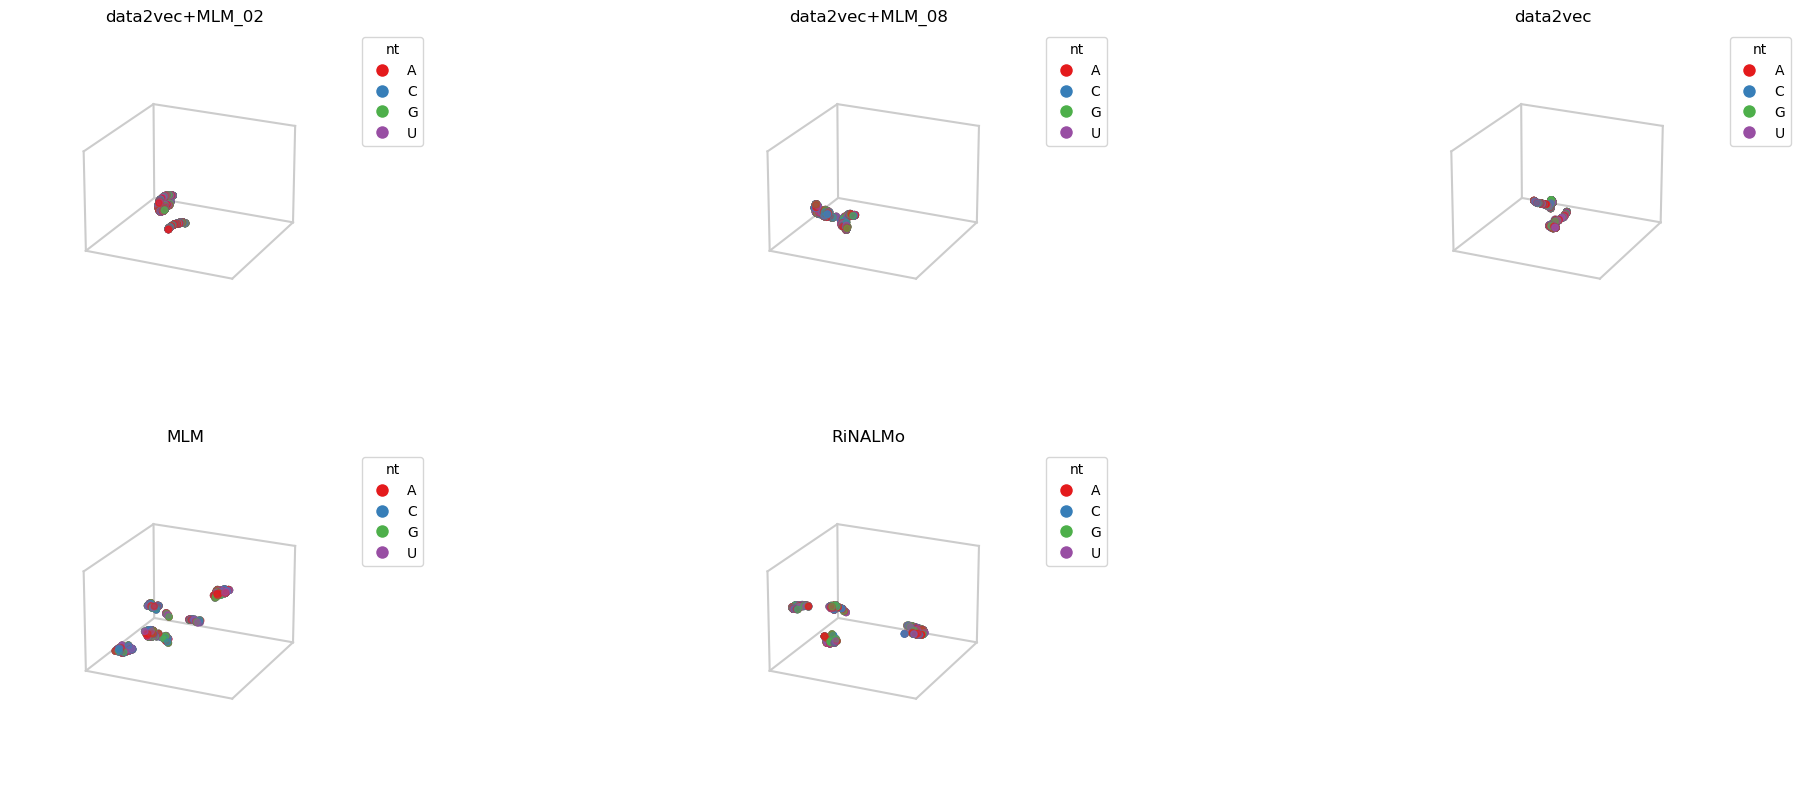

In [34]:
# UMAPの結果のプロット
fig = plt.figure(figsize=(25, 10))

family_name = ["ALL"]  # ファミリーごとにプロットする場合は、family_name = [fam] とする
axes = []
index = 230     # 2行2列のサブプロットの最初の位置から開始
for framework_name, proj in all_umap_projs.items():
    index += 1
    axes.append(fig.add_subplot(index, projection="3d"))
    plot_embedding_3d(proj, framework_name, family_name, axes[-1])

plt.savefig("./results/UMAP/UMAP_3d.png", format="png", dpi=600)

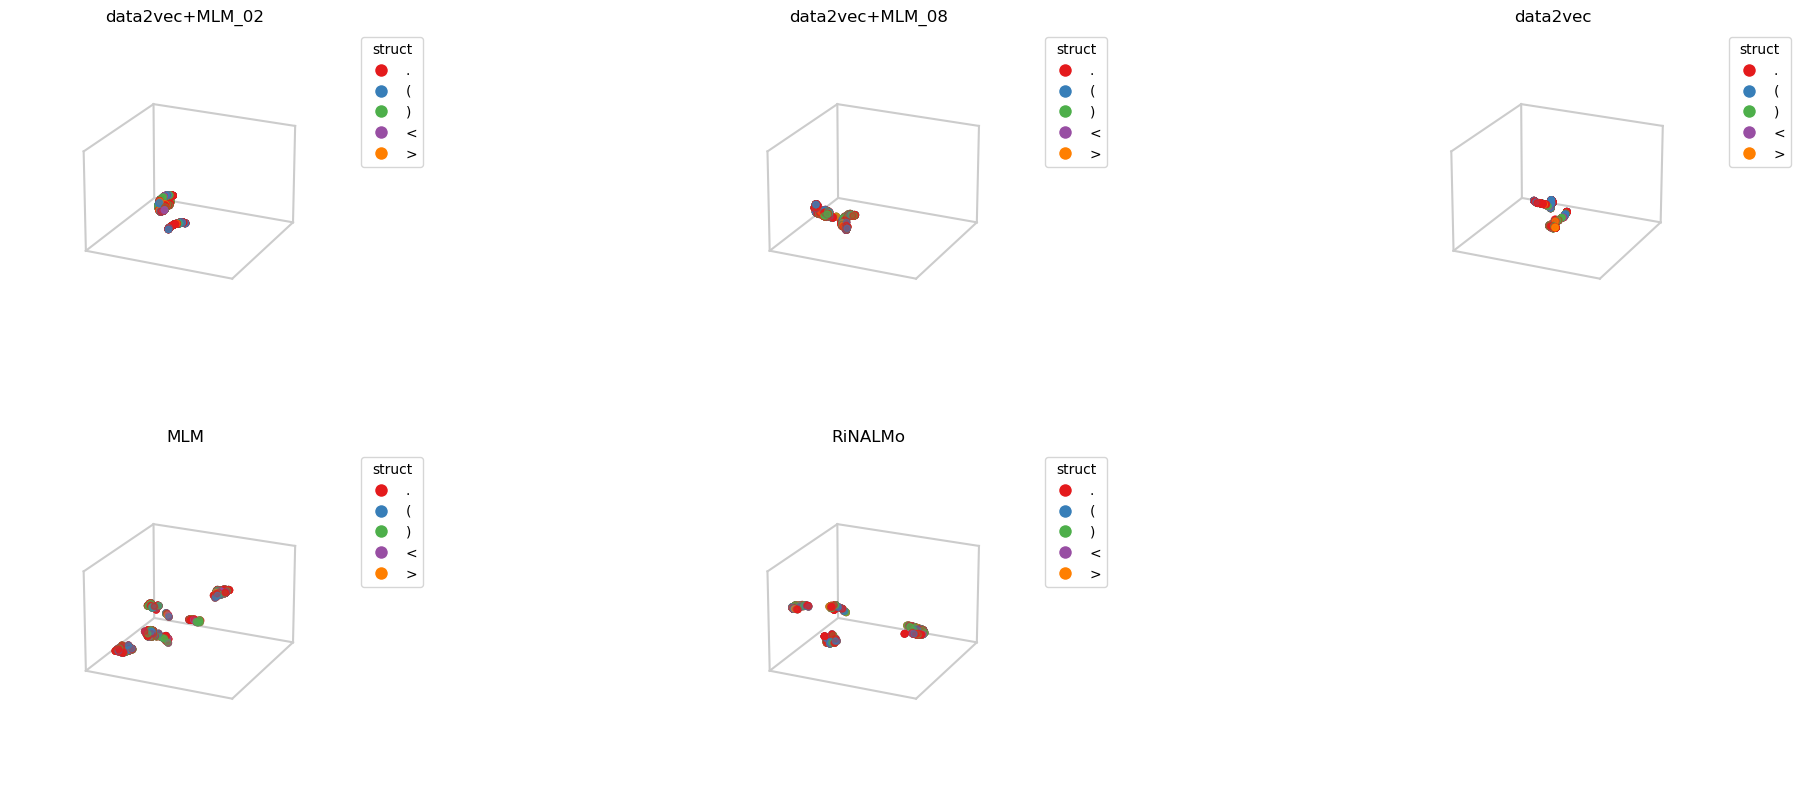

In [35]:
# UMAPの結果のプロット（構造要素ごと）
fig = plt.figure(figsize=(25, 10))

family_name = ["ALL"]  # ファミリーごとにプロットする場合は、family_name = [fam] とする
axes = []
index = 230     # 2行2列のサブプロットの最初の位置から開始
for framework_name, proj in all_umap_projs.items():
    index += 1
    axes.append(fig.add_subplot(index, projection="3d"))
    plot_embedding_3d(proj, framework_name, family_name, axes[-1], type="struct")

plt.savefig("./results/UMAP/UMAP_3d.png", format="png", dpi=600)

#### 2Dの場合

In [15]:
# UMAPによる次元削減
all_umap_projs = {framework_name: [] for framework_name in frameworks}
for framework_name in frameworks:
    print(f"Performing UMAP for {framework_name} - all families...")
    seq_embeddings = [family_representatives[framework_name][fam]["representation"] for fam in family]
    all_umap_projs[framework_name] = get_umap_proj(seq_embeddings, n_components=2)

Performing UMAP for data2vec_mlm_02 - all families...
Performing UMAP for data2vec_mlm_08 - all families...
Performing UMAP for data2vec - all families...
Performing UMAP for mlm - all families...
Performing UMAP for rinalmo - all families...


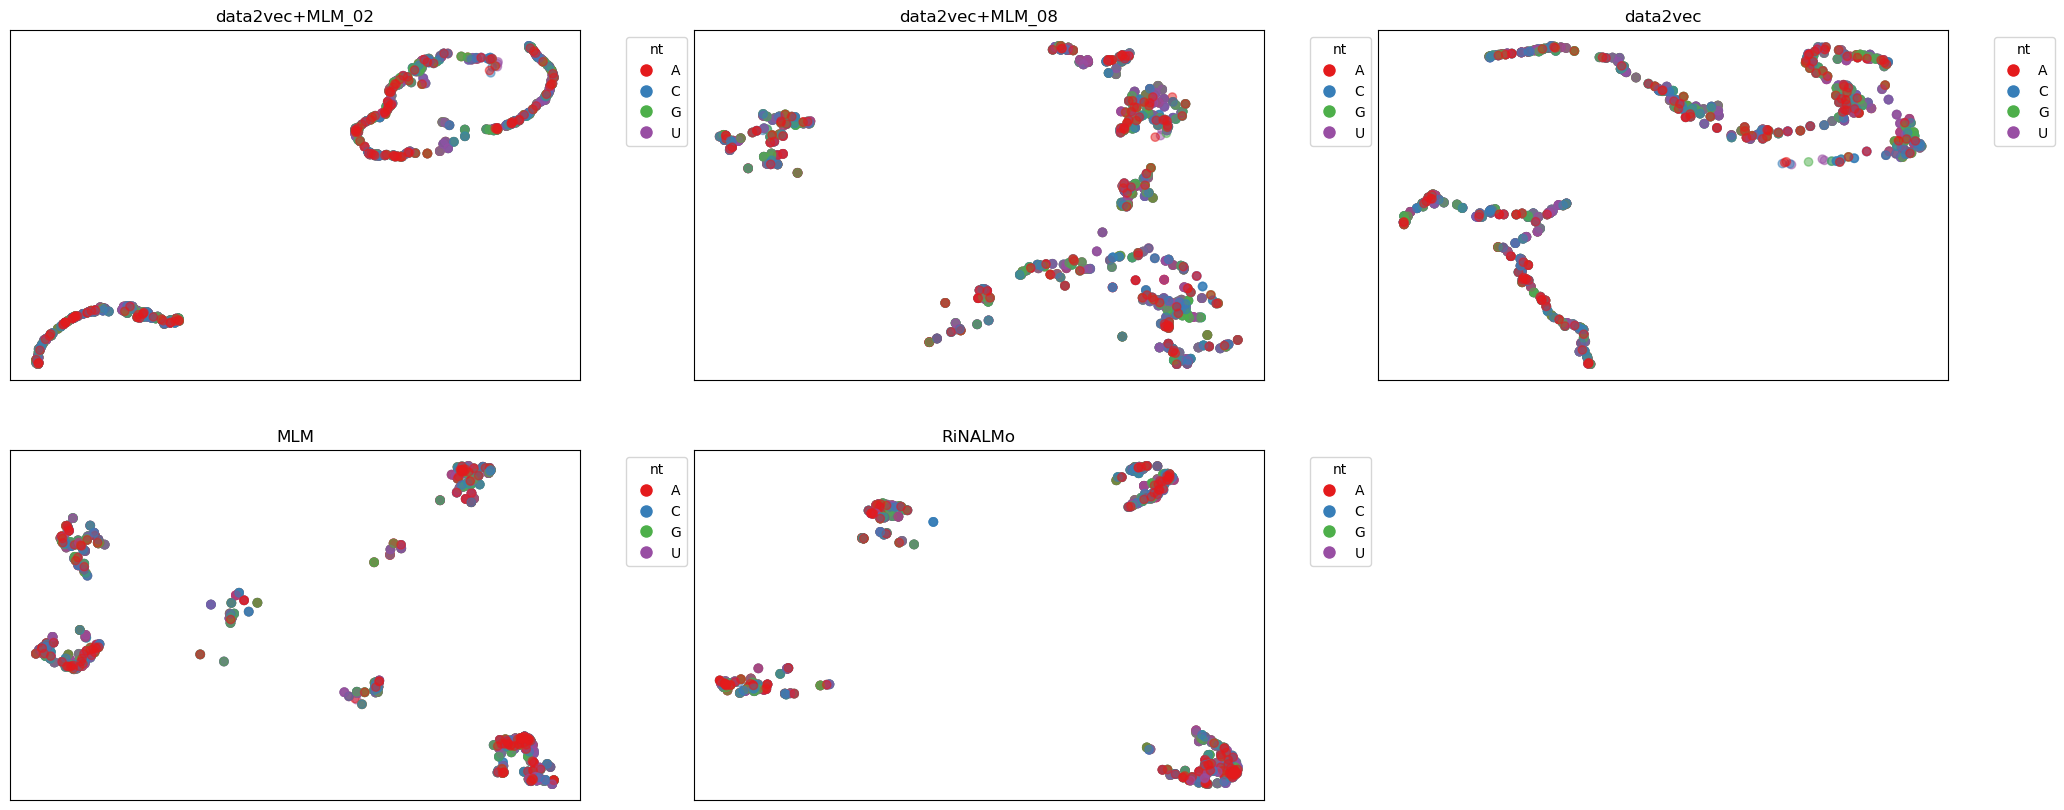

In [32]:
# UMAPの結果のプロット
fig = plt.figure(figsize=(25, 10))

family_name = ["ALL"]  # ファミリーごとにプロットする場合は、family_name = [fam] とする
axes = []
index = 230     # 2行2列のサブプロットの最初の位置から開始
for framework_name, proj in all_umap_projs.items():
    index += 1
    axes.append(fig.add_subplot(index))
    plot_embedding_2d(proj, framework_name, family_name, axes[-1])

plt.savefig("./results/UMAP/UMAP_2d.png", format="png", dpi=600)

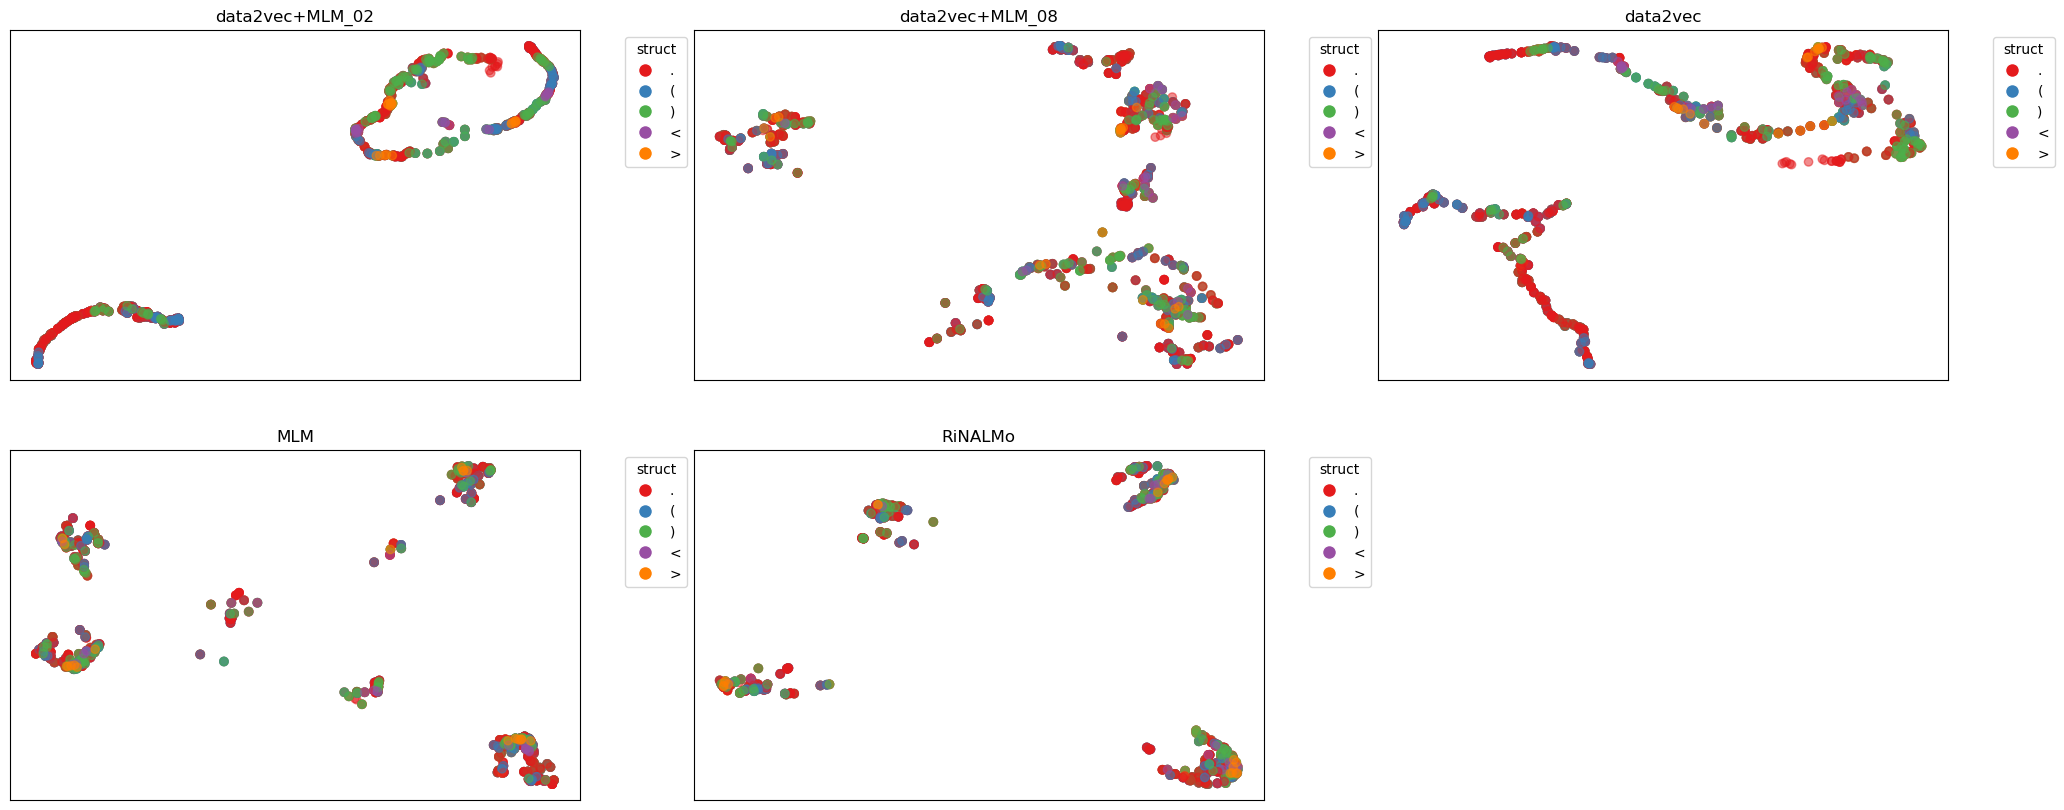

In [31]:
# UMAPの結果のプロット（構造要素ごとに色分け）
fig = plt.figure(figsize=(25, 10))

family_name = ["ALL"]  # ファミリーごとにプロットする場合は、family_name = [fam] とする
axes = []
index = 230     # 2行2列のサブプロットの最初の位置から開始
for framework_name, proj in all_umap_projs.items():
    index += 1
    axes.append(fig.add_subplot(index))
    plot_embedding_2d(proj, framework_name, family_name, axes[-1], type="struct")

plt.savefig("./results/UMAP/UMAP_2d.png", format="png", dpi=600)

## 表現配列がファミリーごとにクラスタを形成しているか

### 準備

In [ ]:



def download_embedding(emb_name):
  return h5py.File(f"../../data/embeddings/{emb_name}_ArchiveII.h5", "r")

def get_umap_proj(id_to_embedding_seq):
  any_embedding = id_to_embedding_seq['tmRNA_Yers.pest._AE017042_1-364'][()]
  n = len(id_to_embedding_seq.keys())
  d = any_embedding.shape[1]
  average_embeddings = np.zeros((n, d))
  for i, entry in enumerate(id_to_embedding_seq.items()):
      seqid, embedding = entry
      numpy_embedding = embedding[()]
      average_embeddings[i] =  np.mean(numpy_embedding, axis=0)
  umap_model = umap.UMAP(random_state=seed, n_components=3)
  return umap_model.fit_transform(average_embeddings)


In [ ]:

llm_id_to_embedding_seq = {}
for llm in emb_names:
    llm_id_to_embedding_seq[llm] = download_embedding(llm)

In [ ]:
# Extract family name from sequence ID
def get_family_name(sequence_id):
    return sequence_id.split('_')[0]

# Extract sequence IDs for each point
sequence_ids = llm_id_to_embedding_seq["one-hot"].keys()

# Extract family names for each sequence ID
family_names = [get_family_name(sequence_id) for sequence_id in sequence_ids]
unique_families = ['23s', 'telomerase', '16s', 'grp1', 'tmRNA', 'RNaseP', 'tRNA', 'srp', '5s']
colors = mpl.colormaps['Set1'].colors
colors_ordered = [colors[2] + (1,), colors[3] + (1,), colors[1]+ (1,), colors[4]+ (.5,), colors[0]+ (.5,), colors[5]+ (.5,), colors[7]+ (.1,), colors[6]+ (.1,), colors[8]+ (.1,)]
zs = [20, 18, 16, 14, 12, 10, 8, 6, 4]
alphas = [1, 1, 1, 0.5, 0.5, 0.5, 0.2, 0.2, 0.2]
family_colors = {family: color for family, color in zip(unique_families, colors_ordered)}
family_markers = {family: marker for family, marker in zip(unique_families, [".", "x", "d", "^", ".", "x", "d", "^", "."])}
family_zs = {family: z for family, z in zip(unique_families, zs)}
family_alphas = {family: alpha for family, alpha in zip(unique_families, alphas)}
zs = [family_zs[family] for family in family_names]
alphas = [family_alphas[family] for family in family_names]
markers = ["." for family in family_names]
order = np.argsort(zs)

In [ ]:
# plotの名前をemb_nameから変えたかったらここに登録
llm_names = {
    "rna-msm": "RNA-MSM",
    "rnafm": "RNA-FM",
    "rnabert": "RNABERT",
}

In [ ]:
llm_proj = {}
for emb_name, id_to_embedding_seq in llm_id_to_embedding_seq.items():
    llm_proj[emb_name] = get_umap_proj(id_to_embedding_seq)

In [ ]:
def plot_embedding(data_points, emb_name, f, colors, unique_families, zs, ax):

  # markers
  #plt.rc('axes.spines', **{'bottom':True, 'left':True, 'right':False, 'top':False})
  #fig = plt.figure()
  #ax=fig.add_subplot(projection='3d')
  # Hide grid lines
  ax.grid(False)

  ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))
  ax.set_axis_off()
  ax.set_ylim(-6.91, 24.93)
  ax.set_xlim(-9.18, 23.48)
  ax.set_zlim(-12.39, 23.63)
  vleng = 22

  i = np.array([vleng, 0, 0])
  j = np.array([0, vleng, 0])
  k = np.array([0, 0, vleng])

  p = np.array([vleng, 0, vleng])
  q = np.array([0, vleng, vleng])
  r = np.array([vleng, vleng, 0])

  ax_color = '0.8'
  ax.plot(*np.vstack([[0,0,0], i]).T, color=ax_color)
  ax.plot(*np.vstack([[0,0,0], j]).T, color=ax_color)
  ax.plot(*np.vstack([[0,0,0], k]).T, color=ax_color)
  ax.plot(*np.vstack([[0,0,vleng], p]).T, color=ax_color)
  ax.plot(*np.vstack([[0,0,vleng], q]).T, color=ax_color)
  ax.plot(*np.vstack([[vleng,0,0], r]).T, color=ax_color)
  ax.plot(*np.vstack([[0,vleng,0], r]).T, color=ax_color)
  ax.plot(*np.vstack([[0,vleng,0], q]).T, color=ax_color)
  ax.plot(*np.vstack([[vleng,0,0], p]).T, color=ax_color)

  ax.view_init(22, 25)
  order = np.argsort(zs)

  colors = mpl.colormaps['Set1'].colors
  colors_ordered = [colors[2] + (1,), colors[3] + (1,), colors[1]+ (1,), colors[4]+ (.5,), colors[0]+ (.5,), colors[5]+ (.5,), colors[7]+ (.1,), colors[6]+ (.1,), colors[8]+ (.1,)]
  zs = [20, 18, 16, 14, 12, 10, 8, 6, 4]
  alphas = [1, 1, 1, 0.5, 0.5, 0.5, 0.2, 0.2, 0.2]
  family_colors = {family: color for family, color in zip(unique_families, colors_ordered)}

  if f !='ALL':
    for family in unique_families:
      if family == f:
        family_colors[family] = (0.8, 0.8, 0.8, 0.005)
    colors = [family_colors[family] for family in family_names]
  else:
    family_markers = {family: marker for family, marker in zip(unique_families, [".", "x", "d", "^", ".", "x", "d", "^", "."])}
    family_zs = {family: z for family, z in zip(unique_families, zs)}
    family_alphas = {family: alpha for family, alpha in zip(unique_families, alphas)}
    zs = [family_zs[family] for family in family_names]
    alphas = [family_alphas[family] for family in family_names]
    markers = ["." for family in family_names]
    order = np.argsort(zs)

    colors = [family_colors[family] for family in family_names]

  sc = ax.scatter(data_points[:, 0][order], data_points[:, 1][order], data_points[:, 2][order], c=[colors[i] for i in order])
  plt.title(f'{llm_names.get(emb_name, emb_name)}')
  plt.tick_params(left = False, right = False , labelleft = False , labelbottom = False, bottom = False)

### UMAPによる可視化

In [ ]:
#@title Visualize projections with a given family { run: "auto" }
#@markdown Select family to be highlighted in the embeddings.

#@markdown ---
fam_name = 'ALL' #@param ["ALL","tmRNA","16s","23s","grp1","telomerase","RNaseP","srp","tRNA","5s"]
#@markdown ---

fig = plt.figure(figsize=(25, 10))

axes = []
# ncol = 2
# nrow = len(llm_proj) // ncol + 1
# index = 0
index = 220
for emb_name, proj in llm_proj.items():
    index += 1
    # axes.append(fig.add_subplot((nrow, ncol, index), projection="3d"))
    axes.append(fig.add_subplot(index, projection="3d"))
    plot_embedding(proj, emb_name, fam_name, colors, unique_families, zs, axes[-1])

plt.savefig("figs/UMAP.png", format="png", dpi=600)